# Evidence for Histogram mismatch between different cases
### Clearly see that different MRI camera vendors have their different intensity distribution
This highlights the need to perform strong value scaling.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import animation
import random
import time
#PATH PROCESS
import os
import os.path
from pathlib import Path
import glob

import helpers

# the one library to handle nii images
import nibabel as nib

In [2]:
PROBLEM_TYPE = "CINE" 
IMAGE_TYPE = "4CH"
DATASET_FOLDER_PATH = os.path.abspath(f".\\CMR-MULTI\\{PROBLEM_TYPE}_MULTI\\{IMAGE_TYPE}_TR\\image")

all_images = helpers.get_all_np_images(DATASET_FOLDER_PATH)

max value in all pixels for the image number 35 is 4934.10205078125
max value in all pixels for the image number 77 is 4152.90869140625
max value in all pixels for the image number 69 is 6908.58740234375


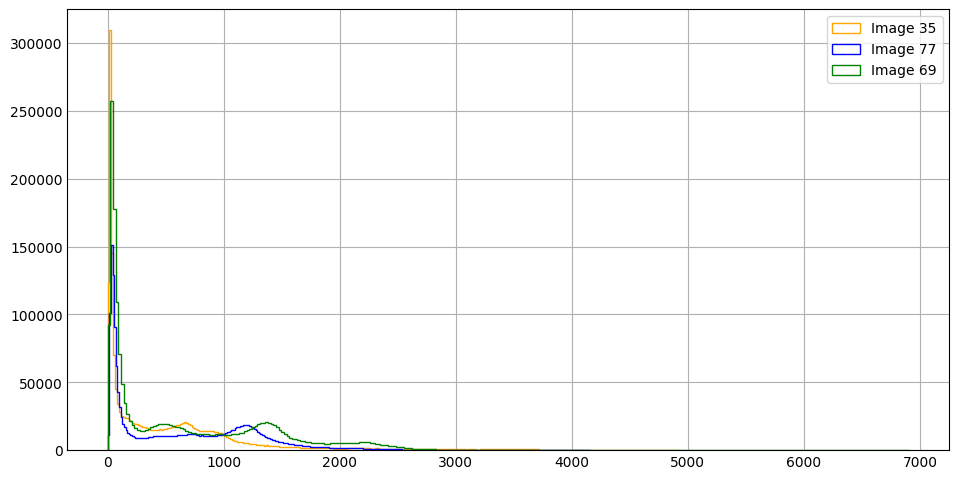

In [3]:
random_indices = np.random.randint(0, len(all_images), 3)
randomly_selected_images = [all_images[i] for i in random_indices]
colors = ['orange', 'blue', 'green']

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")

    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()

### Trying out the min-max scaler

(217025575, 1)
max value in all pixels for the image number 35 is 1.0
max value in all pixels for the image number 77 is 0.9999999999999999
max value in all pixels for the image number 69 is 1.0000000000000002


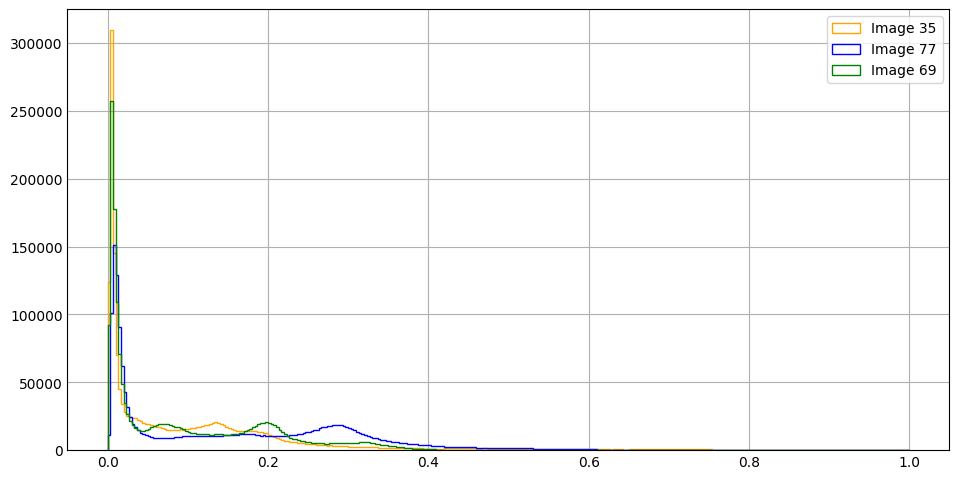

In [4]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()

all_pixels = np.array(helpers.recursive_flatten(all_images)).reshape(-1, 1)
print(all_pixels.shape)
scaler = scaler.fit(all_pixels)

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img = scaler.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")

    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()

(217025575, 1)
max value in all pixels for the image number 35 is 6.544770479958961
max value in all pixels for the image number 77 is 5.835255592590585
max value in all pixels for the image number 69 is 8.891925840822632


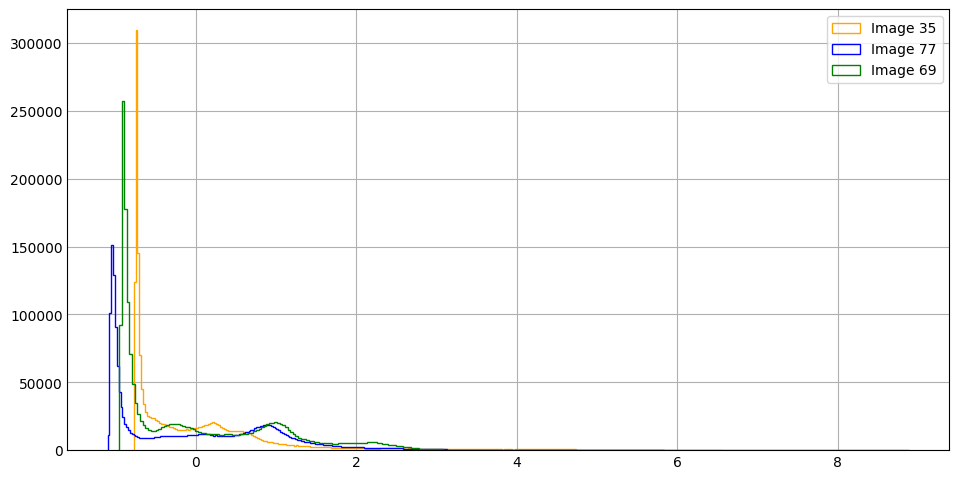

In [5]:
from sklearn.preprocessing import StandardScaler

zscaler = StandardScaler()

print(all_pixels.shape)
zscaler = zscaler.fit(all_pixels)

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img = zscaler.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")

    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()
    

(217025575, 1)
max value in all pixels for the image number 35 is 6.401723877557649
max value in all pixels for the image number 77 is 3.38141900747501
max value in all pixels for the image number 69 is 5.6006707240960365


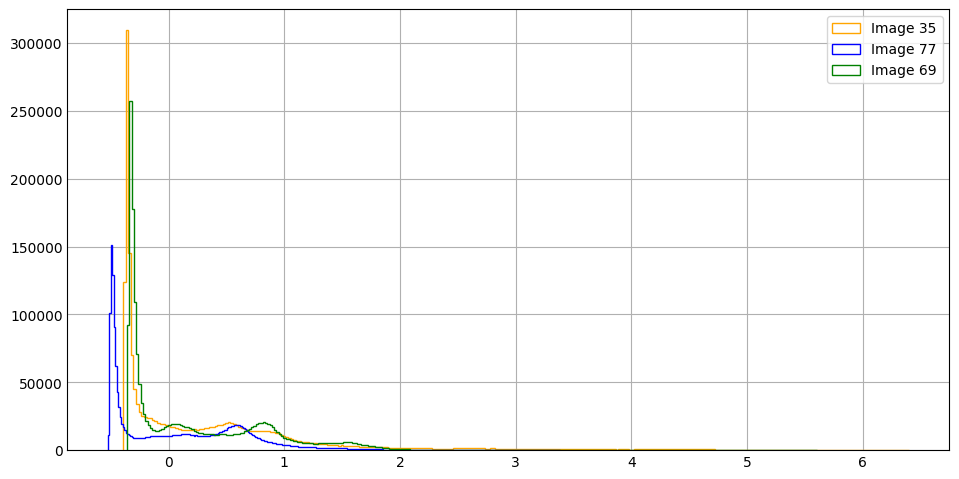

In [6]:
from sklearn.preprocessing import RobustScaler

rbscaler = RobustScaler()

print(all_pixels.shape)
rbscaler = rbscaler.fit(all_pixels)

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img = rbscaler.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")
    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()

### Looks like the StandardScaler (Z-score scaler) achieves a good histogrm matching between the 3 randomly selected cases
#### Now let's try to manually clip out the outlier data and rerun the Z-Scaler

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm


def clip_outliers_from_img(image:np.ndarray):
    original_shape = image.shape
    p1, p99 = np.percentile(image.reshape(-1, 1), [1, 99])
    pixels = np.clip(image.reshape(-1, 1), p1, p99)
    clipped_img = pixels.reshape(original_shape)
    return clipped_img, pixels



all_pixels_after_clipping = []
for img in tqdm(all_images):
    clipped_img, pixels = clip_outliers_from_img(img)
    allall_pixels_after_clipping = np.concatenate((all_pixels_after_clipping, pixels))

print(f"finished clipping {len(all_images)} images")

#all_pixels_after_clipping = helpers.recursive_flatten(clipped_images)
all_pixels_after_clipping = np.array(all_pixels_after_clipping).reshape(-1, 1)

print(f"finished flattening {len(all_images)} images to {len(all_pixels_after_clipping)} pixels")

zscaler_clipped = StandardScaler()
zscaler_clipped = zscaler_clipped.fit(all_pixels_after_clipping)

print(f"finished training the scaler")

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img = clip_outliers_from_img(img) #Clip outliers
    img = zscaler_clipped.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")
    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()

100%|██████████| 105/105 [07:44<00:00,  4.42s/it]


In [ ]:
minmax_clipped = MinMax()
minmax_clipped = minmax_clipped.fit(all_pixels_after_clipping)

print(f"finished training the scaler")

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img = clip_outliers_from_img(img) #Clip outliers
    img = minmax_clipped.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")
    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()

In [ ]:
minmax_clipped = MinMax()
minmax_clipped = minmax_clipped.fit(all_pixels_after_clipping)

print(f"finished training the scaler")

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img = clip_outliers_from_img(img) #Clip outliers
    img = minmax_clipped.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")
    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()